# Image-Reliance Report — `mask2former_ms` (CocoFreeView test split)

Reads the per-sample store written by [`src/notebooks/save_image_reliance.py`](../notebooks/save_image_reliance.py)
and reports three of its diagnostics:

1. **Regression error in pixels** on the test set — *clean* run vs. *image-shuffled* run.
2. **Deformable sampling in-range percentage** — for every (module × layer × resolution):
   two modules (fixation decoder, eye decoder) × 4 layers × 3 resolutions.
4. **Deformable cross-attention residual norms** per layer, for the eye decoder and the fixation decoder.

*(Section 3 — arrow plots of where the deformable attention points — is intentionally omitted:
the raw `sampling_locations`, image pixels, and fixation coordinates it needs were not persisted
by the save script; only the aggregated in-range fraction was.)*

## Setup

In [1]:
import os
import json
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ── Locate the store (works whether the notebook runs from src/notebooks or the project root) ──
_CANDIDATES = [
    os.path.join("Output", "image_reliance", "mask2former_ms_reliance.h5"),
    os.path.join("..", "..", "Output", "image_reliance", "mask2former_ms_reliance.h5"),
]
H5_PATH = next((p for p in _CANDIDATES if os.path.exists(p)), _CANDIDATES[0])
SUMMARY_PATH = H5_PATH.replace("_reliance.h5", "_summary.json")
print("Store  :", os.path.abspath(H5_PATH))

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.axisbelow": True, "font.size": 10})

Store  : c:\Users\ulloa\Miooooo\Master\thesis\Projects\From-Noisy-Eye-Tracking-To-Scanpath\Output\image_reliance\mask2former_ms_reliance.h5


In [2]:
# ── Load everything into memory (the small per-sample arrays; skip the big float16 residual dumps) ──
SKIP = {"dec_first_cross_res", "dec_second_cross_res"}   # (N, 4, 21, 512) fp16 — not needed here
D, ATTRS = {}, {}
with h5py.File(H5_PATH, "r") as f:
    g = f["/reliance"]
    for k in g:
        if k not in SKIP:
            D[k] = g[k][()]
    ATTRS = dict(g.attrs)

N        = int(len(D["sample_idx"]))
IMG_SIZE = int(ATTRS.get("img_size", 512))
N_DEC    = int(ATTRS.get("n_decoder", 4))
N_EYE    = int(ATTRS.get("n_eye_decoder", 4))

# spatial_shapes = [h0,w0, h1,w1, h2,w2] -> per-level resolution labels (coarse -> fine)
ss = np.asarray(ATTRS.get("spatial_shapes", [8, 8, 16, 16, 32, 32])).reshape(-1, 2)
LEVEL_LABELS = [f"L{i} ({h}x{w})" for i, (h, w) in enumerate(ss)]
N_LVL = len(LEVEL_LABELS)

print(f"N samples = {N}   img_size = {IMG_SIZE}px")
print(f"fixation decoder layers = {N_DEC}   eye decoder layers = {N_EYE}   resolutions = {LEVEL_LABELS}")
print("residual legend:  fixation 1st-cross =", ATTRS.get("fix_first_cross"),
      "| fixation 2nd-cross =", ATTRS.get("fix_second_cross"),
      "| eye cross =", ATTRS.get("eye_cross"))

N samples = 7018   img_size = 256px
fixation decoder layers = 4   eye decoder layers = 4   resolutions = ['L0 (8x8)', 'L1 (16x16)', 'L2 (32x32)']
residual legend:  fixation 1st-cross = gaze | fixation 2nd-cross = image | eye cross = image


## 1) Regression error in pixels — clean vs. image-shuffled

`reg_error_*` is the mean Euclidean distance between predicted and target fixation positions in
**normalised** `[0,1]` coordinates. Multiplying by `img_size` (256 px) gives the error in pixels.

- **clean** — the model's own test-set prediction error.
- **shuffled** — same forward, but each image is swapped for another sample's image (gaze untouched).
  If the model relied on the image, this should get worse.

In [3]:
px = IMG_SIZE
clean_px = D["reg_error_clean"] * px
shuf_px  = D["reg_error_shuffled"] * px
valid = ~np.isnan(clean_px) & ~np.isnan(shuf_px)
clean_v, shuf_v = clean_px[valid], shuf_px[valid]
delta = shuf_v - clean_v

def _row(name, a):
    return {"run": name, "mean_px": a.mean(), "median_px": np.median(a),
            "std_px": a.std(), "p90_px": np.percentile(a, 90)}

tbl = pd.DataFrame([_row("clean", clean_v), _row("shuffled", shuf_v)]).set_index("run").round(3)
print(f"Valid samples: {valid.sum()} / {N}\n")
print("Position error (pixels):")
display(tbl)

abs_d = delta.mean()
rel_d = abs_d / clean_v.mean()
print(f"\nMean shuffle penalty : {abs_d:+.3f} px  ({rel_d:+.1%} of clean)")
print(f"Median shuffle penalty: {np.median(delta):+.3f} px")
print(f"Samples that got worse when shuffled: {(delta > 0).mean():.1%}")

Valid samples: 7018 / 7018

Position error (pixels):


,mean_px,median_px,std_px,p90_px
run,,,,
clean,31.211000,26.944000,17.900999,56.012001
shuffled,32.592999,28.924999,17.458000,56.792000



Mean shuffle penalty : +1.382 px  (+4.4% of clean)
Median shuffle penalty: +0.929 px
Samples that got worse when shuffled: 58.1%


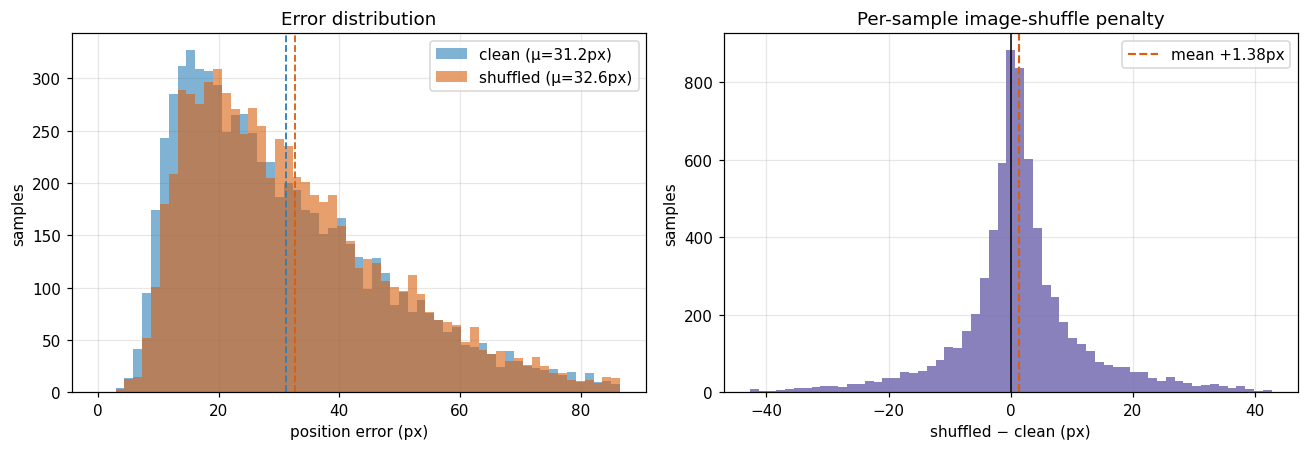

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

# Distributions, clean vs shuffled
bins = np.linspace(0, np.percentile(np.concatenate([clean_v, shuf_v]), 99), 60)
ax[0].hist(clean_v, bins=bins, alpha=0.6, label=f"clean (μ={clean_v.mean():.1f}px)", color="#2c7fb8")
ax[0].hist(shuf_v,  bins=bins, alpha=0.6, label=f"shuffled (μ={shuf_v.mean():.1f}px)", color="#d95f0e")
ax[0].axvline(clean_v.mean(), color="#2c7fb8", ls="--", lw=1.2)
ax[0].axvline(shuf_v.mean(),  color="#d95f0e", ls="--", lw=1.2)
ax[0].set(xlabel="position error (px)", ylabel="samples", title="Error distribution")
ax[0].legend()

# Per-sample penalty (shuffled - clean)
lim = np.percentile(np.abs(delta), 99)
ax[1].hist(delta, bins=np.linspace(-lim, lim, 60), color="#756bb1", alpha=0.85)
ax[1].axvline(0, color="k", lw=1)
ax[1].axvline(delta.mean(), color="#d95f0e", ls="--", lw=1.4, label=f"mean {delta.mean():+.2f}px")
ax[1].set(xlabel="shuffled − clean (px)", ylabel="samples",
          title="Per-sample image-shuffle penalty")
ax[1].legend()
plt.tight_layout(); plt.show()

## 2) Deformable sampling in-range percentage

Fraction of deformable sampling locations that land **inside** the `[0,1]` feature map (locations
outside are zero-padded by `grid_sample`, wasting attention weight). Stored per sample as
`dec_inrange` / `eye_inrange`, each shaped `(N, 4 layers, 3 resolutions)`.

Below, every one of the **2 modules × 4 layers × 3 resolutions** cells is reported: heatmaps of the
mean in-range %, a full table, and the per-sample spread.

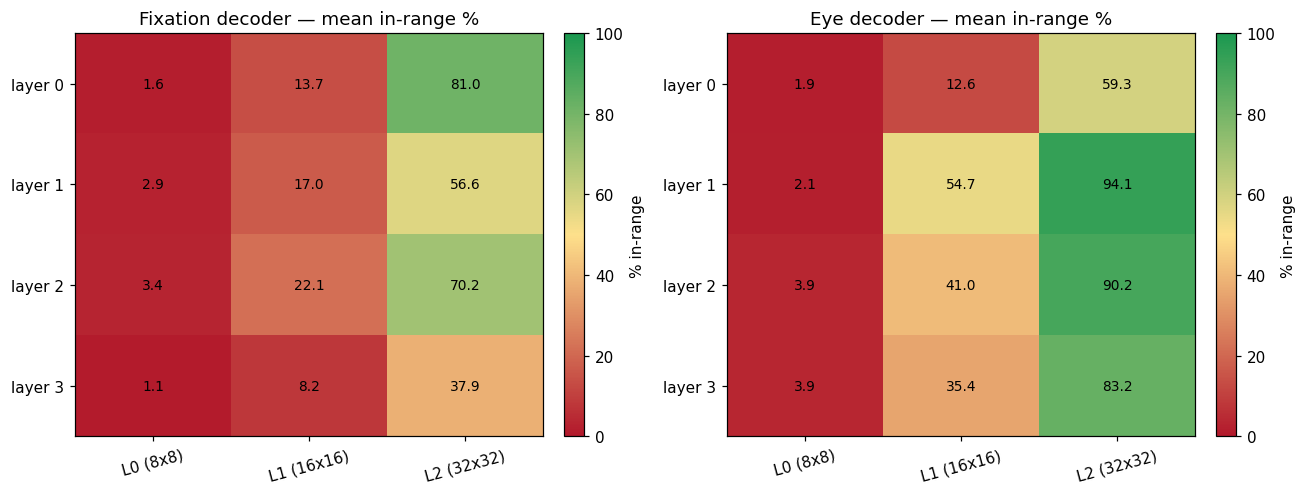

In [5]:
dec_ir = D["dec_inrange"] * 100.0   # (N, N_DEC, N_LVL) percent
eye_ir = D["eye_inrange"] * 100.0   # (N, N_EYE, N_LVL) percent

modules = [("Fixation decoder", dec_ir, N_DEC), ("Eye decoder", eye_ir, N_EYE)]

# Green(good)->red(bad) colormap, fixed 0..100 scale so the two heatmaps are comparable
cmap = LinearSegmentedColormap.from_list("gyr", ["#b2182b", "#fee08b", "#1a9850"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, (name, ir, nl) in zip(axes, modules):
    M = np.nanmean(ir, axis=0)                     # (layers, levels)
    im = ax.imshow(M, cmap=cmap, vmin=0, vmax=100, aspect="auto")
    ax.set_xticks(range(N_LVL)); ax.set_xticklabels(LEVEL_LABELS, rotation=15)
    ax.set_yticks(range(nl));    ax.set_yticklabels([f"layer {i}" for i in range(nl)])
    ax.set_title(f"{name} — mean in-range %"); ax.grid(False)
    for i in range(nl):
        for j in range(N_LVL):
            ax.text(j, i, f"{M[i,j]:.1f}", ha="center", va="center",
                    color="black", fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="% in-range")
plt.tight_layout(); plt.show()

In [6]:
# ── Full table: one row per (module, layer, resolution) ──
rows = []
for name, ir, nl in modules:
    for l in range(nl):
        for j in range(N_LVL):
            col = ir[:, l, j]
            col = col[~np.isnan(col)]
            rows.append({
                "module": name, "layer": l, "resolution": LEVEL_LABELS[j],
                "mean_%": col.mean(), "median_%": np.median(col),
                "std_%": col.std(), "min_%": col.min(), "max_%": col.max(),
            })
ir_tbl = pd.DataFrame(rows).round(2)
display(ir_tbl.style.hide(axis="index")
        .background_gradient(cmap="RdYlGn", vmin=0, vmax=100, subset=["mean_%"]))

module,layer,resolution,mean_%,median_%,std_%,min_%,max_%
Fixation decoder,0,L0 (8x8),1.600000,1.560000,0.690000,0.000000,5.510000
Fixation decoder,0,L1 (16x16),13.700000,13.620000,2.120000,7.590000,23.209999
Fixation decoder,0,L2 (32x32),81.000000,81.250000,2.520000,66.459999,87.980003
Fixation decoder,1,L0 (8x8),2.920000,2.900000,0.970000,0.000000,7.370000
Fixation decoder,1,L1 (16x16),16.959999,17.070000,1.870000,9.820000,23.070000
Fixation decoder,1,L2 (32x32),56.650002,57.080002,4.480000,38.959999,69.709999
Fixation decoder,2,L0 (8x8),3.370000,3.320000,1.180000,0.480000,11.720000
Fixation decoder,2,L1 (16x16),22.120001,22.080000,3.010000,11.460000,32.570000
Fixation decoder,2,L2 (32x32),70.180000,70.419998,3.940000,50.220001,82.169998
Fixation decoder,3,L0 (8x8),1.130000,1.040000,0.780000,0.000000,5.590000


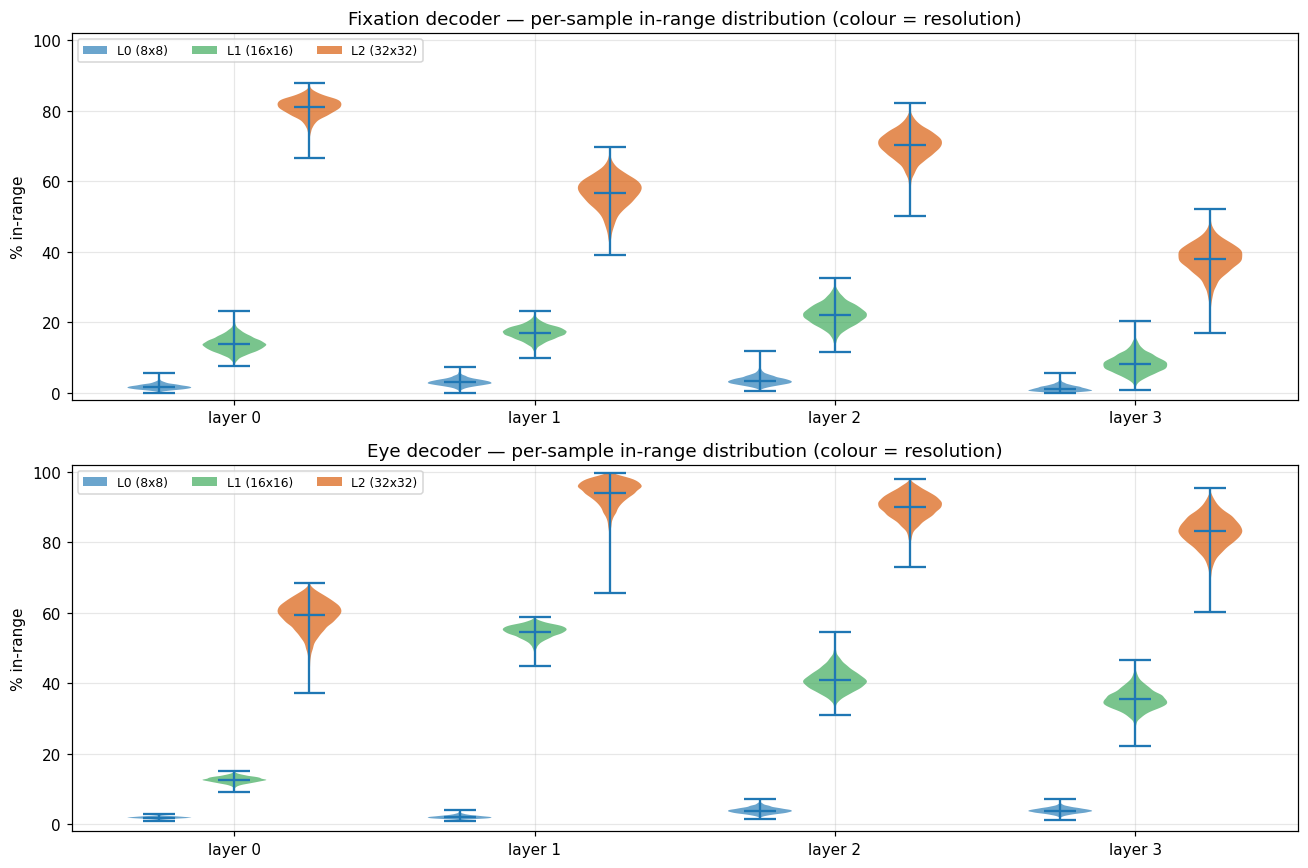

In [7]:
# ── Per-sample spread for every cell (violin per resolution, grouped by layer) ──
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
colors = ["#2c7fb8", "#41ab5d", "#d95f0e"]
for ax, (name, ir, nl) in zip(axes, modules):
    positions, data, tick_pos, tick_lab = [], [], [], []
    p = 0
    for l in range(nl):
        for j in range(N_LVL):
            col = ir[:, l, j]; col = col[~np.isnan(col)]
            data.append(col); positions.append(p); p += 1
        tick_pos.append(p - 2); tick_lab.append(f"layer {l}")
        p += 1  # gap between layers
    parts = ax.violinplot(data, positions=positions, showmeans=True, widths=0.85)
    for k, b in enumerate(parts["bodies"]):
        b.set_facecolor(colors[k % N_LVL]); b.set_alpha(0.7)
    ax.set_xticks(tick_pos); ax.set_xticklabels(tick_lab)
    ax.set_ylabel("% in-range"); ax.set_ylim(-2, 102)
    ax.set_title(f"{name} — per-sample in-range distribution (colour = resolution)")
    handles = [plt.Rectangle((0, 0), 1, 1, fc=colors[j], alpha=0.7) for j in range(N_LVL)]
    ax.legend(handles, LEVEL_LABELS, loc="upper left", fontsize=8, ncol=3)
plt.tight_layout(); plt.show()

## 4) Deformable cross-attention residual norms per layer

The residual each cross-attention block adds to the stream (L2 norm over the feature dim, averaged
over decode steps and samples). The **deformable (image) cross-attention** is the highlighted stream
in each decoder:

- **Fixation decoder** — `second_cross` is the image (deformable); `first_cross` is the gaze
  cross-attention, shown for context, plus self-attention and FFN.
- **Eye decoder** — `cross_attention` is the image (deformable); self-attention and FFN shown for context.

Values are NaN-padded per sample beyond its valid query length, so aggregation uses `nanmean`.

In [8]:
def layer_means(key):
    # Mean residual norm per layer: nanmean over (samples, valid query positions).
    arr = D[key]                      # (N, n_layers, T)
    per_sample = np.nanmean(arr, axis=2)     # (N, n_layers)
    return np.nanmean(per_sample, axis=0), np.nanstd(per_sample, axis=0)  # (n_layers,), (n_layers,)

fix_streams = [
    ("image (2nd cross, deformable)", "dec_second_cross_res_norm", True),
    ("gaze (1st cross)",              "dec_first_cross_res_norm",  False),
    ("self-attention",               "dec_self_attention_res_norm", False),
    ("FFN",                          "dec_ffn_res_norm",           False),
]
eye_streams = [
    ("image (cross, deformable)", "eye_cross_attention_res_norm", True),
    ("self-attention",           "eye_self_attention_res_norm",  False),
    ("FFN",                      "eye_ffn_res_norm",             False),
]

def build_table(streams, n_layers):
    out = {}
    for label, key, _ in streams:
        m, _s = layer_means(key)
        out[label] = m
    df = pd.DataFrame(out, index=[f"layer {i}" for i in range(n_layers)])
    return df

fix_df = build_table(fix_streams, N_DEC)
eye_df = build_table(eye_streams, N_EYE)
print("Fixation decoder — mean residual norm per layer:"); display(fix_df.round(3))
print("Eye decoder — mean residual norm per layer:");      display(eye_df.round(3))

Fixation decoder — mean residual norm per layer:


,"image (2nd cross, deformable)",gaze (1st cross),self-attention,FFN
layer 0,12.775000,29.111000,35.318001,42.858002
layer 1,13.512000,42.945999,18.591000,40.127998
layer 2,26.181999,64.489998,33.584000,24.778999
layer 3,7.228000,156.927994,35.103001,36.369999


Eye decoder — mean residual norm per layer:


,"image (cross, deformable)",self-attention,FFN
layer 0,3.876000,17.075001,70.482002
layer 1,39.837002,43.261002,16.573999
layer 2,32.446999,76.111000,15.743000
layer 3,64.892998,51.519001,26.170000


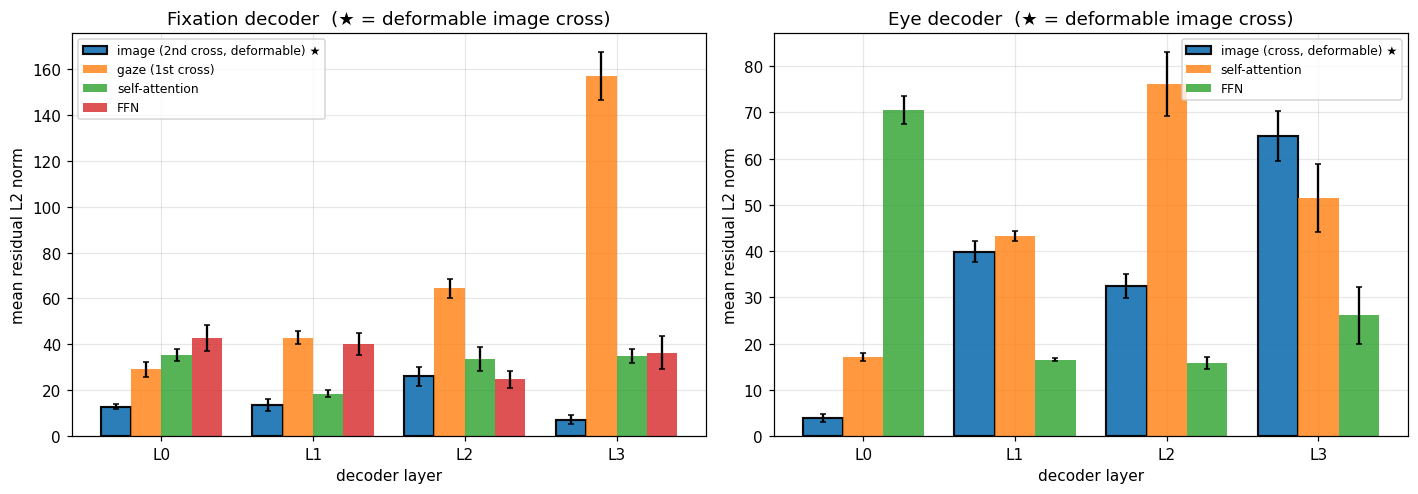

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
x_fix = np.arange(N_DEC)
x_eye = np.arange(N_EYE)

def plot_decoder(ax, streams, n_layers, title):
    x = np.arange(n_layers)
    w = 0.8 / len(streams)
    for k, (label, key, is_deform) in enumerate(streams):
        m, s = layer_means(key)
        off = (k - (len(streams) - 1) / 2) * w
        bars = ax.bar(x + off, m, width=w, yerr=s, capsize=2,
                      label=label + (" ★" if is_deform else ""),
                      edgecolor="black" if is_deform else "none",
                      linewidth=1.4 if is_deform else 0, alpha=0.95 if is_deform else 0.8)
    ax.set_xticks(x); ax.set_xticklabels([f"L{i}" for i in range(n_layers)])
    ax.set_xlabel("decoder layer"); ax.set_ylabel("mean residual L2 norm")
    ax.set_title(title); ax.legend(fontsize=8)

plot_decoder(axes[0], fix_streams, N_DEC, "Fixation decoder  (★ = deformable image cross)")
plot_decoder(axes[1], eye_streams, N_EYE, "Eye decoder  (★ = deformable image cross)")
plt.tight_layout(); plt.show()

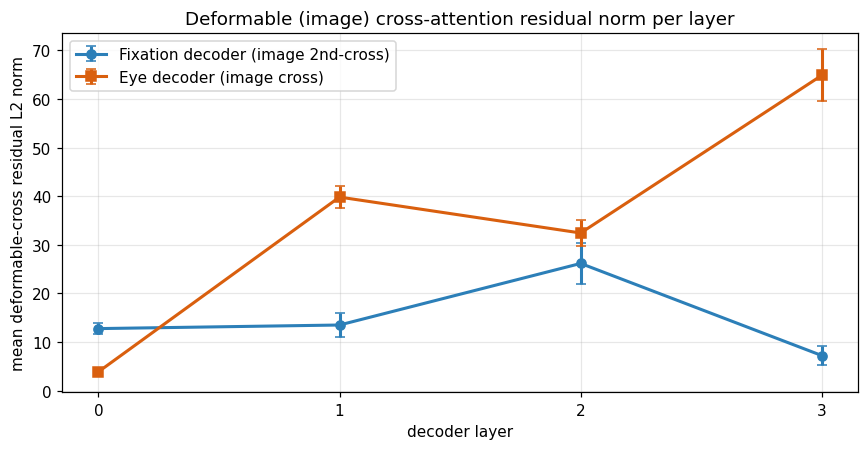

In [10]:
# ── Focused view: the deformable (image) residual per layer, both decoders ──
fig, ax = plt.subplots(figsize=(8, 4.2))
fm, fs = layer_means("dec_second_cross_res_norm")
em, es = layer_means("eye_cross_attention_res_norm")
ax.errorbar(np.arange(N_DEC), fm, yerr=fs, marker="o", capsize=3,
            label="Fixation decoder (image 2nd-cross)", color="#2c7fb8", lw=2)
ax.errorbar(np.arange(N_EYE), em, yerr=es, marker="s", capsize=3,
            label="Eye decoder (image cross)", color="#d95f0e", lw=2)
ax.set_xticks(np.arange(max(N_DEC, N_EYE)))
ax.set_xlabel("decoder layer"); ax.set_ylabel("mean deformable-cross residual L2 norm")
ax.set_title("Deformable (image) cross-attention residual norm per layer")
ax.legend(); plt.tight_layout(); plt.show()